In [2]:
from asyncio import current_task

import pandas as pd
import ssl

from matplotlib.lines import lineStyles

ssl._create_default_https_context = ssl._create_unverified_context

fish = pd.read_csv('https://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [14]:
fish_input = fish[['Weight','Length','Diagonal','Height','Width']].to_numpy()
fish_target = fish['Species'].to_numpy()
print(fish_target)

['Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Roach'
 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach'
 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach'
 'Roach' 'Whitefish' 'Whitefish' 'Whitefish' 'Whitefish' 'Whitefish'
 'Whitefish' 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Parkki'
 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'

In [7]:
from sklearn.model_selection import train_test_split
import numpy as np


np.set_printoptions(precision=6, suppress=True)
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)
print('train_input')
print(train_input)


train_input
[[ 720.       35.       40.6      16.3618    6.09  ]
 [ 500.       45.       48.        6.96      4.896 ]
 [   7.5      10.5      11.6       1.972     1.16  ]
 [ 110.       22.       23.5       5.5225    3.995 ]
 [ 140.       20.7      23.2       8.5376    3.2944]
 [  69.       18.2      20.3       5.2983    2.8217]
 [ 110.       21.       22.5       5.6925    3.555 ]
 [ 620.       34.5      39.7      15.5227    5.2801]
 [ 130.       21.3      22.8       6.384     3.534 ]
 [  85.       20.       21.        5.082     2.772 ]
 [ 685.       36.5      39.       10.881     6.864 ]
 [ 500.       31.       36.2      14.3714    4.8146]
 [ 514.       32.8      34.       10.03      6.018 ]
 [ 200.       23.       25.8      10.3458    3.6636]
 [1000.       44.       46.6      12.4888    7.5958]
 [ 714.       36.       41.5      16.517     5.8515]
 [   8.7      11.3      12.6       1.9782    1.2852]
 [1000.       43.       45.2      11.9328    7.2772]
 [ 110.       20.8      23.1      

In [8]:
print(train_input.shape)

(119, 5)


In [13]:
print('test_input')
print(test_input)

test_input
[[  78.       18.7      19.4       5.1992    3.1234]
 [  13.4      12.4      13.5       2.43      1.269 ]
 [ 200.       32.3      34.8       5.568     3.3756]
 [ 270.       26.       28.7       8.3804    4.2476]
 [ 150.       23.       24.5       5.2185    3.626 ]
 [1000.       37.       42.6      18.957     6.603 ]
 [   7.       10.6      11.6       1.7284    1.1484]
 [ 180.       25.2      27.9       7.0866    3.906 ]
 [ 188.       24.6      26.2       6.7334    4.1658]
 [1250.       56.       59.7      10.6863    6.9849]
 [ 650.       33.5      38.7      14.4738    5.7276]
 [1000.       40.       43.5      12.354     6.525 ]
 [ 600.       32.       37.2      15.438     5.58  ]
 [ 150.       20.       22.4       8.8928    3.2928]
 [ 700.       35.       40.5      16.2405    5.589 ]
 [ 920.       38.5      44.1      18.0369    6.3063]
 [1000.       43.5      46.       12.604     8.142 ]
 [ 218.       26.5      28.        7.168     4.144 ]
 [ 225.       24.       25.5       

In [15]:
print(test_input.shape)

(40, 5)


In [11]:
print('train_target')
print(train_target)

train_target
['Bream' 'Pike' 'Smelt' 'Perch' 'Parkki' 'Roach' 'Perch' 'Bream' 'Perch'
 'Perch' 'Perch' 'Bream' 'Perch' 'Parkki' 'Perch' 'Bream' 'Smelt' 'Perch'
 'Roach' 'Bream' 'Pike' 'Bream' 'Pike' 'Perch' 'Parkki' 'Bream' 'Perch'
 'Pike' 'Bream' 'Perch' 'Parkki' 'Roach' 'Perch' 'Bream' 'Roach' 'Perch'
 'Bream' 'Bream' 'Perch' 'Perch' 'Roach' 'Pike' 'Perch' 'Smelt' 'Pike'
 'Roach' 'Perch' 'Parkki' 'Perch' 'Bream' 'Perch' 'Smelt' 'Perch' 'Parkki'
 'Smelt' 'Perch' 'Perch' 'Roach' 'Bream' 'Perch' 'Perch' 'Roach' 'Roach'
 'Perch' 'Perch' 'Bream' 'Roach' 'Bream' 'Roach' 'Parkki' 'Perch' 'Perch'
 'Perch' 'Perch' 'Pike' 'Pike' 'Perch' 'Bream' 'Perch' 'Bream' 'Whitefish'
 'Pike' 'Bream' 'Bream' 'Roach' 'Perch' 'Pike' 'Bream' 'Pike' 'Parkki'
 'Roach' 'Perch' 'Roach' 'Smelt' 'Whitefish' 'Roach' 'Perch' 'Bream'
 'Whitefish' 'Smelt' 'Pike' 'Roach' 'Smelt' 'Bream' 'Roach' 'Pike' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Smelt' 'Bream' 'Parkki' 'Perch'
 'Bream' 'Perch' 'Perch']


In [18]:
print(test_target)

['Perch' 'Smelt' 'Pike' 'Whitefish' 'Perch' 'Bream' 'Smelt' 'Roach'
 'Perch' 'Pike' 'Bream' 'Whitefish' 'Bream' 'Parkki' 'Bream' 'Bream'
 'Perch' 'Perch' 'Perch' 'Bream' 'Smelt' 'Bream' 'Bream' 'Bream' 'Bream'
 'Perch' 'Perch' 'Whitefish' 'Smelt' 'Smelt' 'Pike' 'Perch' 'Perch' 'Pike'
 'Bream' 'Perch' 'Roach' 'Roach' 'Parkki' 'Perch']


In [19]:
from sklearn.preprocessing import StandardScaler
ss= StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)
print(train_scaled[:7])

[[ 0.919658  0.609432  0.810412  1.851949  1.000757]
 [ 0.300412  1.546534  1.453166 -0.469817  0.272917]
 [-1.085854 -1.68647  -1.708486 -1.701598 -2.004476]
 [-0.797341 -0.608802 -0.674869 -0.824806 -0.276315]
 [-0.712899 -0.730625 -0.700927 -0.08023  -0.703387]
 [-0.912746 -0.964901 -0.952816 -0.880172 -0.991536]
 [-0.797341 -0.702512 -0.761728 -0.782825 -0.54453 ]]


In [20]:
print(test_scaled[:7])

[[-0.887414 -0.918046 -1.030989 -0.904645 -0.807625]
 [-1.069247 -1.50842  -1.543455 -1.588496 -1.938032]
 [-0.544014  0.356414  0.306633 -0.81357  -0.653889]
 [-0.346981 -0.233961 -0.223205 -0.11905  -0.122335]
 [-0.684751 -0.515091 -0.588011 -0.899878 -0.50125 ]
 [ 1.707789  0.796852  0.984129  2.492831  1.313472]
 [-1.087261 -1.677099 -1.708486 -1.761755 -2.011547]]


In [31]:
from sklearn.linear_model import  SGDClassifier
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))


0.7899159663865546
0.825


C:\python_study\AI\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [32]:
sc.partial_fit(train_scaled, train_target)  # partial_fit 부분학습추가
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))


0.8067226890756303
0.8


In [34]:
import numpy as np
sc = SGDClassifier(loss='log_loss',random_state=42)
train_score = []
test_score = []
classes = np.unique(fish_target)
for _ in range(0,300):
    sc.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

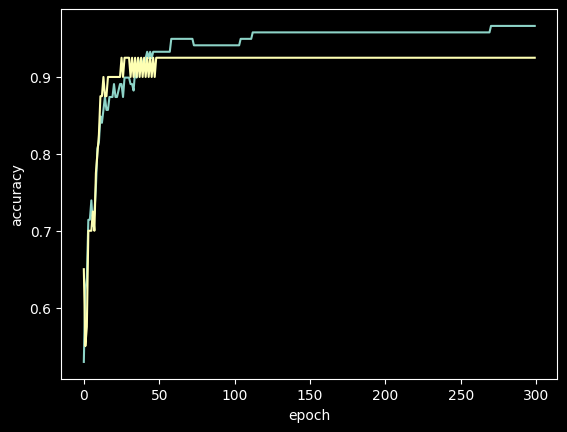

In [35]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [39]:
sc = SGDClassifier(loss='log_loss', max_iter=100, tol= None, random_state=42)   # 100번학습
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [37]:
sc.predict(test_scaled[:10])
proba = sc.predict_proba(test_scaled[:10])
np.round(proba, decimals=3)

array([[0.   , 0.003, 0.774, 0.   , 0.219, 0.   , 0.005],
       [0.   , 0.001, 0.015, 0.   , 0.04 , 0.945, 0.   ],
       [0.   , 0.   , 0.011, 0.96 , 0.02 , 0.008, 0.001],
       [0.   , 0.   , 0.525, 0.   , 0.423, 0.   , 0.052],
       [0.   , 0.   , 0.688, 0.   , 0.306, 0.   , 0.006],
       [0.997, 0.   , 0.   , 0.   , 0.   , 0.   , 0.002],
       [0.   , 0.001, 0.024, 0.   , 0.058, 0.917, 0.   ],
       [0.   , 0.   , 0.144, 0.   , 0.836, 0.   , 0.019],
       [0.   , 0.   , 0.709, 0.   , 0.275, 0.   , 0.016],
       [0.   , 0.   , 0.095, 0.905, 0.   , 0.   , 0.   ]])

In [38]:
sc.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype='<U9')

In [40]:
sc_hinge = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42)  # 힌지 사용 가장안전하게 나누는 선이다~!!!
sc_hinge.fit(train_scaled, train_target)
print(sc_hinge.score(train_scaled, train_target))
print(sc_hinge.score(test_scaled, test_target))


0.9495798319327731
0.925


In [41]:
sc_hinge.predict(test_scaled[:10])

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch', 'Bream', 'Smelt',
       'Roach', 'Perch', 'Pike'], dtype='<U9')

In [42]:
sc_hinge.partial_fit(train_scaled, train_target)
print(sc_hinge.score(train_scaled, train_target))
print(sc_hinge.score(test_scaled, test_target))

0.907563025210084
0.925


In [43]:
from sklearn.metrics import hinge_loss
train_score = []
test_score = []
train_loss = []
test_loss = []
classes = np.unique(fish_target)

sc_hinge_test = SGDClassifier(loss='hinge', max_iter=1, tol=None, random_state=42)
for _ in range(300):
    sc_hinge_test.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sc_hinge_test.score(train_scaled, train_target))
    test_score.append(sc_hinge_test.score(test_scaled, test_target))

    train_decision = sc_hinge_test.decision_function(train_scaled)
    test_decision = sc_hinge_test.decision_function(test_scaled)

    train_loss.append(hinge_loss(train_target, train_decision))
    test_loss.append(hinge_loss(test_target, test_decision))


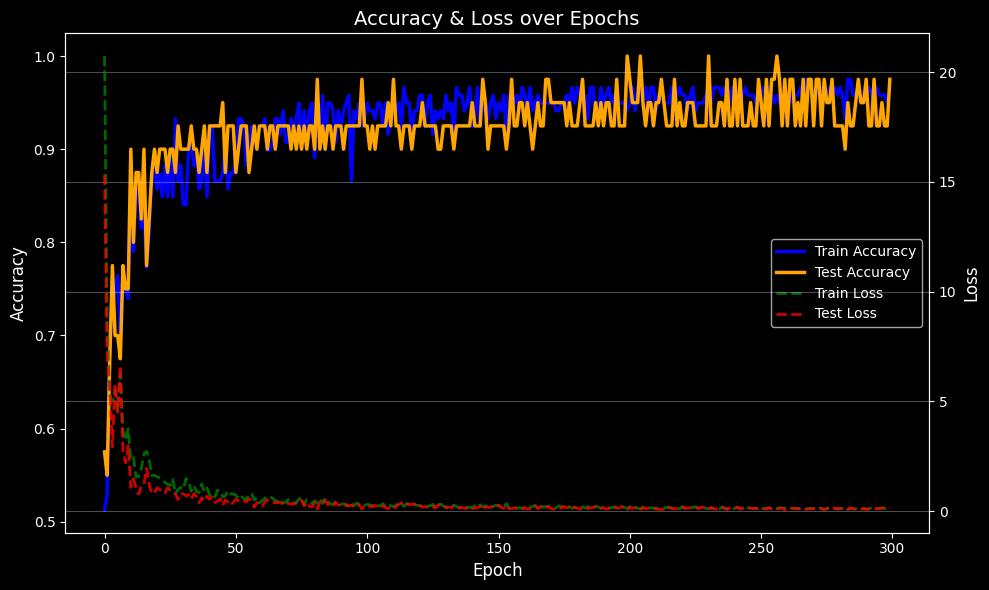

In [51]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(train_score,
         color='blue',
         linewidth=2.5,
         label='Train Accuracy')

ax1.plot(test_score,
         color='orange',
         linewidth=2.5,
         label='Test Accuracy')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()

ax2.plot(train_loss,
         color='green',
         linestyle='--',
         linewidth=2,
         alpha=0.8,
         label='Train Loss')
ax2.plot(test_loss,
         color='red',
         linestyle='--',
         linewidth=2,
         alpha=0.8,
         label='Test Loss')

ax2.set_ylabel('Loss', fontsize=12)


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Accuracy & Loss over Epochs', fontsize=14)  # 그래프 제목 설정
plt.grid(alpha=0.3)  # 배경 격자 추가 (투명도 0.3 → 은은하게)
plt.tight_layout()  # 그래프 요소들이 겹치지 않도록 자동 정렬
plt.show()

In [52]:
patience = 10

best_loss = float('inf')

patience_counter = 0
early_stop_epoch = 0

train_score_early = []
test_score_early = []
train_loss_early = []
test_loss_early = []

sc_hinge_test_early = SGDClassifier(loss='hinge', max_iter=1, tol=None, random_state=42)

for epoch in range(300):
    sc_hinge_test_early.partial_fit(train_scaled, train_target, classes=classes)

    train_score_early.append(sc_hinge_test_early.score(train_scaled, train_target))
    test_score_early.append(sc_hinge_test_early.score(test_scaled, test_target))

    train_decision_early = sc_hinge_test_early.decision_function(train_scaled)
    test_decision_early = sc_hinge_test_early.decision_function(test_scaled)

    current_test_loss = hinge_loss(test_target, test_decision_early)
    train_loss_early.append(hinge_loss(train_target, train_decision_early))
    test_loss_early.append(current_test_loss)

    if current_test_loss < best_loss:
        best_loss = current_test_loss
        patience_counter = 0
        early_stop_epoch = epoch
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch}')
        break


Early stopping at epoch 23


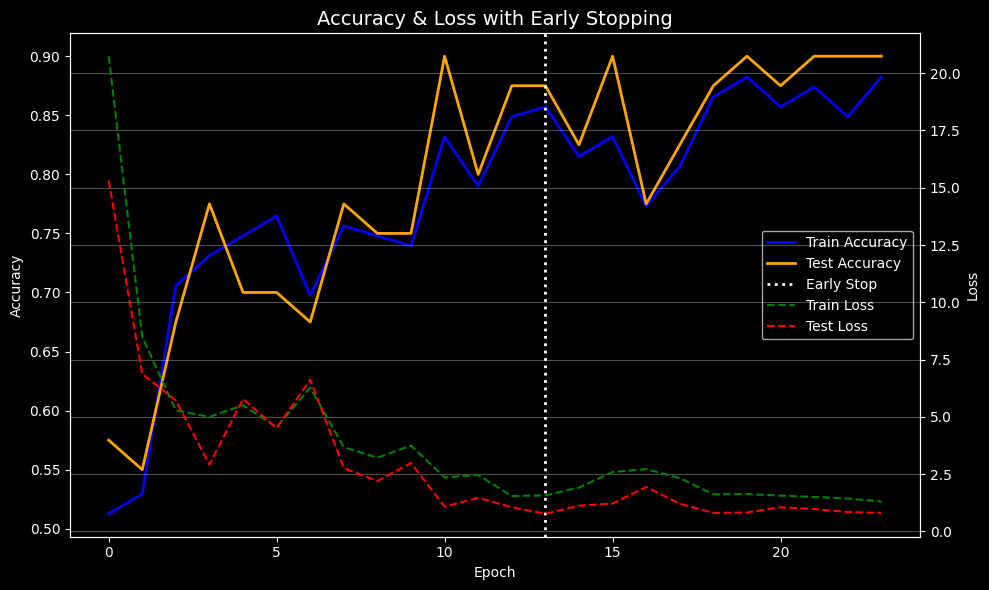

In [53]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(train_score_early, color='blue', linewidth=2, label='Train Accuracy')
ax1.plot(test_score_early, color='orange', linewidth=2, label='Test Accuracy')

ax1.axvline(x=early_stop_epoch,
            color='white',
            linestyle=':',
            linewidth=2,
            label='Early Stop')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')

ax2 = ax1.twinx()
ax2.plot(train_loss_early, color='green', linestyle='--', label='Train Loss')
ax2.plot(test_loss_early, color='red', linestyle='--', label='Test Loss')
ax2.set_ylabel('Loss')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Accuracy & Loss with Early Stopping', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
